<a href="https://colab.research.google.com/github/YujieLiu666/NEON_gapfill_test/blob/main/workflow_XGB_google_colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Before get started

In [1]:
# !pip uninstall -y xgboost
# !pip install xgboost==1.7.5 --quiet


In [2]:
import os, sys
from pathlib import Path
import importlib

# 1. Clone your GitHub repo (downloading all files)
!rm -rf NEON_gapfill_test
!git clone https://github.com/YujieLiu666/NEON_gapfill_test.git

# 2. Change directory into the cloned repo
%cd NEON_gapfill_test

# 3. Pull the latest changes from GitHub
!git pull origin main

# 4. Add the repo folder to Python’s module search path
repo_root = Path(os.getcwd())
sys.path.append(str(repo_root))

# 5. Now import your function module
import function_XGB
importlib.reload(function_XGB)
from function_XGB import *

# 6. Set working directories you'll use for data, models, etc.
site_data_dir = repo_root
model_dir = site_data_dir / "XGB_models"
model_dir.mkdir(exist_ok=True)

# 7. Print current directory and file list to check
print("Current working directory:", os.getcwd())
!ls -l


Cloning into 'NEON_gapfill_test'...
remote: Enumerating objects: 642, done.
remote: Counting objects: 100% (96/96), done.
remote: Compressing objects: 100% (72/72), done.
remote: Total 642 (delta 62), reused 48 (delta 24), pack-reused 546 (from 2)
Receiving objects: 100% (642/642), 51.13 MiB | 23.21 MiB/s, done.
Resolving deltas: 100% (401/401), done.
/content/NEON_gapfill_test
From https://github.com/YujieLiu666/NEON_gapfill_test
 * branch            main       -> FETCH_HEAD
Already up to date.
Python version: 3.12.11 (main, Jun  4 2025, 08:56:18) [GCC 11.4.0]
NumPy version: 2.0.2
Pandas version: 2.2.2
scikit-learn version: 1.6.1
xgboost version: 1.7.5
Matplotlib version: 3.10.0
Python version: 3.12.11 (main, Jun  4 2025, 08:56:18) [GCC 11.4.0]
NumPy version: 2.0.2
Pandas version: 2.2.2
scikit-learn version: 1.6.1
xgboost version: 1.7.5
Matplotlib version: 3.10.0
Current working directory: /content/NEON_gapfill_test
total 63048
-rw-r--r-- 1 root root 21902005 Oct  7 04:40 data_for_XGB

# Load data
function: `load_data`
- Load data from a CSV file into a `pandas.DataFrame`.
- Plot the target variable (`y_col`) over time to visualize its distribution and missing values.
- Plot

## What is GCC?
GCC stands for Green Chromatic Coordinate. It is a vegetation index commonly derived from PhenoCam images (near-surface digital cameras monitoring vegetation phenology).
PhenoCam data for US-xBR (NEON BART):
https://phenocam.nau.edu/webcam/sites/NEON.D01.BART.DP1.00033/



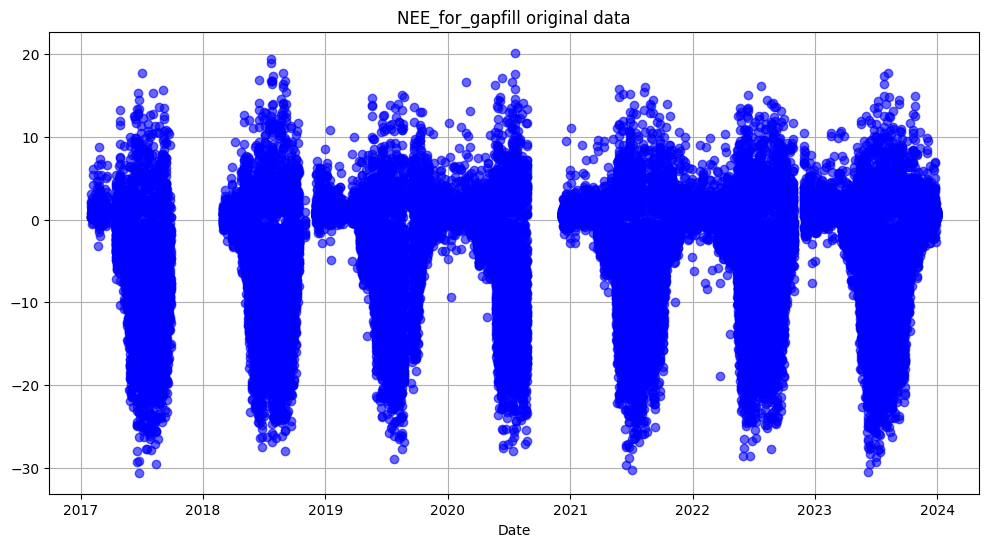

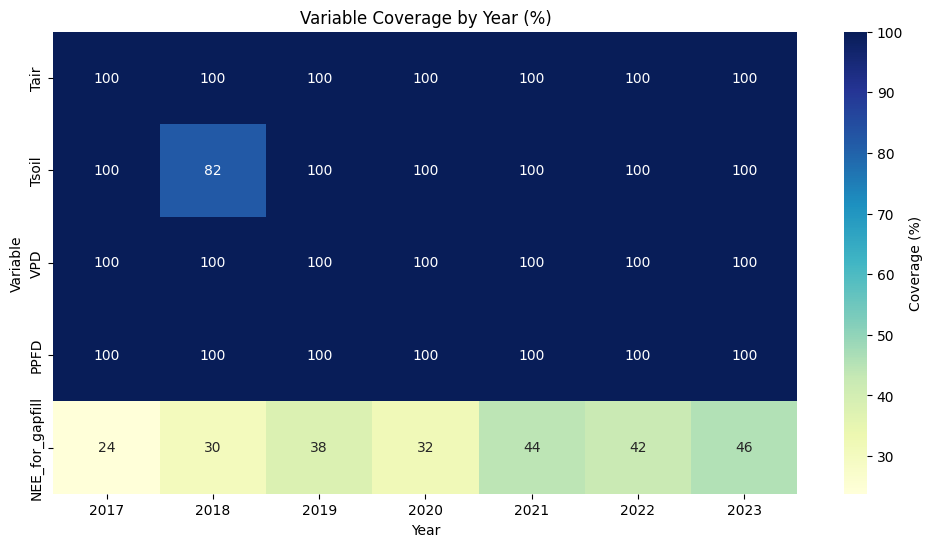

In [3]:
predictors = ['TIMESTAMP_END', 'GCC', 'EVI', 'Tair', 'VPD', 'PPFD']
y_col = "NEE_for_gapfill"
file_name = "data_for_XGB_BART_NEON.csv"
site_data = load_data(site_data_dir, file_name, y_col, plot=True)

# 01 Hyperparamter tuning

The `find_hyperparameters` function is designed to optimize an XGBoost regression model by performing a grid search over a predefined set of hyperparameters using 10-fold cross-validation. It returns the trained model as `.pkl` for future use.

Parameters:

- `site_data` (`pandas.DataFrame`)  
  Input dataset containing predictors and target variable.
- `predictors` (*list of str*): Column names to be used as predictors (X).  
- `y_col` (*str*): Name of the response variable (y).  
- `model_dir` (*Path* or *str*): Directory to save the model and best parameters.  
- `n_jobs` (*int*): Number of parallel jobs for GridSearchCV.  




In [4]:
# This line takes a long time to run (> 5 hours), please keep it commented for the tutorial
# HPC users: If running on a multi-core system, limit thread usage
# to prevent oversubscription (set environment variables before importing packages)
# Uncomment and adjust as needed:

# os.environ['OMP_NUM_THREADS'] = '1'
# os.environ['MKL_NUM_THREADS'] = '1'
# os.environ['OPENBLAS_NUM_THREADS'] = '1'
# os.environ['BLIS_NUM_THREADS'] = '1'

# Set n_jobs based on HPC scheduler:
# n_jobs = int(os.getenv("SLURM_CPUS_PER_TASK", 1))

# find_hyperparameters(site_data, predictors, y_col, model_dir, n_jobs = 10)


# Instead, load the model after hyperparameter tuning
model_path = model_dir / f"XGB_model_{y_col}.pkl"
reg = joblib.load(model_path)

# 02 Check model performance
`check_model_performance`: Perform model evaluation with k-fold cross-validation

- Shuffle data into `k` folds (default: `n_folds = 10`)  
- Train XGBoost (or other estimator) on each fold  
- Plot learning curves for each fold  
- Compute mean and standard deviation of RMSE, R², and MAPE across folds  

**Parameters**

- `site_data` (`pandas.DataFrame`)  
  Input dataset containing predictors and target variable.

- `predictors` (`list` of `str`)  
  List of column names in `site_data` to be used as predictors (features).

- `y_col` (`str`)  
  Column name of the target variable in `site_data`.

- `reg` (`object`)  
  Regression model object with `fit`, `predict`, and `evals_result` methods  
  (e.g., `XGBRegressor`).

- `n_folds` (`int`, optional, default=10`)  
  Number of folds for cross-validation.


Step 1: Shuffle & assign folds ...
Step 2: Train & evaluate for each fold ...
 Processing Fold 1...
  Train model for Fold 1...
  Plotting learning curve for Fold 1...


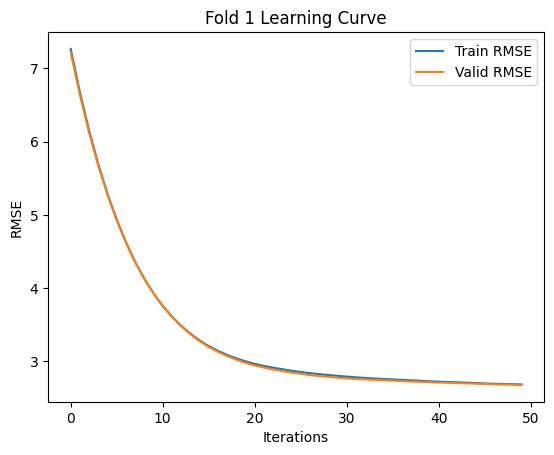

{'RMSE': np.float64(2.679266761285985), 'R2': 0.851272094199456, 'MAPE': np.float64(88.50658462819388)}
 Processing Fold 2...
  Train model for Fold 2...
  Plotting learning curve for Fold 2...


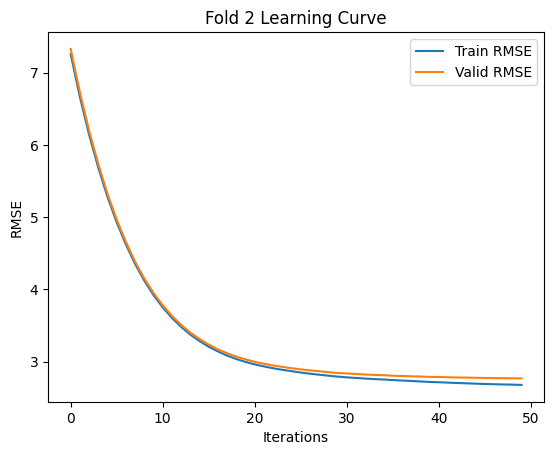

{'RMSE': np.float64(2.7670694244614), 'R2': 0.8418298542780164, 'MAPE': np.float64(91.57963361405727)}
 Processing Fold 3...
  Train model for Fold 3...
  Plotting learning curve for Fold 3...


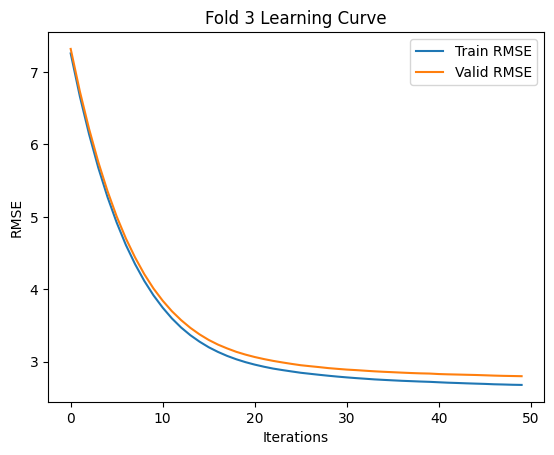

{'RMSE': np.float64(2.8002674346539993), 'R2': 0.839239135903412, 'MAPE': np.float64(79.60900061413845)}
 Processing Fold 4...
  Train model for Fold 4...
  Plotting learning curve for Fold 4...


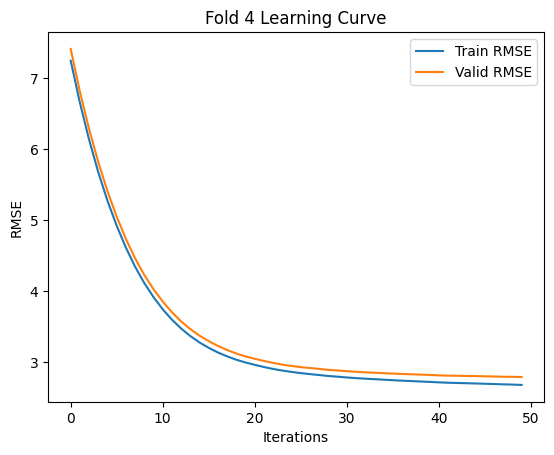

{'RMSE': np.float64(2.7883128949821674), 'R2': 0.8458584182559266, 'MAPE': np.float64(82.70656135132694)}
 Processing Fold 5...
  Train model for Fold 5...
  Plotting learning curve for Fold 5...


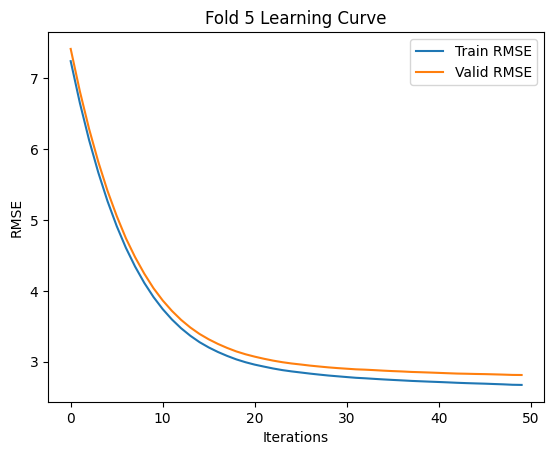

{'RMSE': np.float64(2.8102271785223887), 'R2': 0.8416194282786569, 'MAPE': np.float64(88.22363035083673)}
 Processing Fold 6...
  Train model for Fold 6...
  Plotting learning curve for Fold 6...


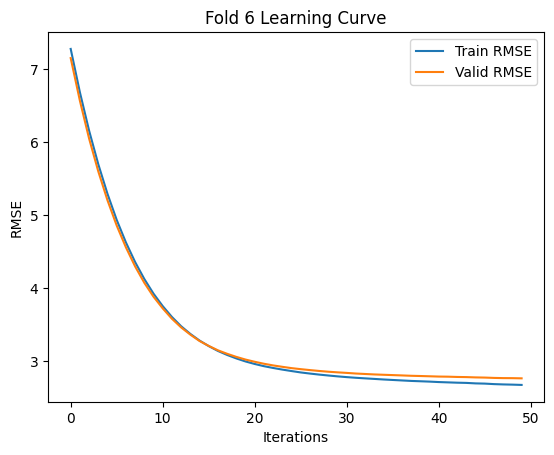

{'RMSE': np.float64(2.764675309448936), 'R2': 0.8392195237555858, 'MAPE': np.float64(80.45455636912209)}
 Processing Fold 7...
  Train model for Fold 7...
  Plotting learning curve for Fold 7...


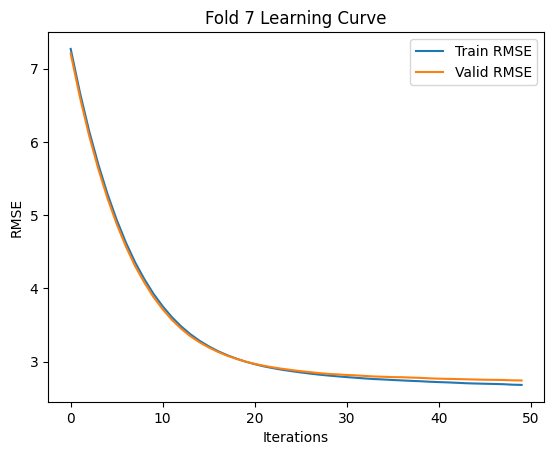

{'RMSE': np.float64(2.742128611482703), 'R2': 0.8435350110083815, 'MAPE': np.float64(83.73589523247263)}
 Processing Fold 8...
  Train model for Fold 8...
  Plotting learning curve for Fold 8...


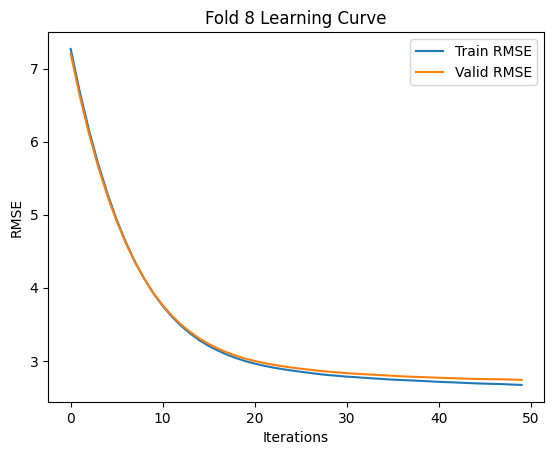

{'RMSE': np.float64(2.738945927500877), 'R2': 0.844079577619114, 'MAPE': np.float64(80.8722058896405)}
 Processing Fold 9...
  Train model for Fold 9...
  Plotting learning curve for Fold 9...


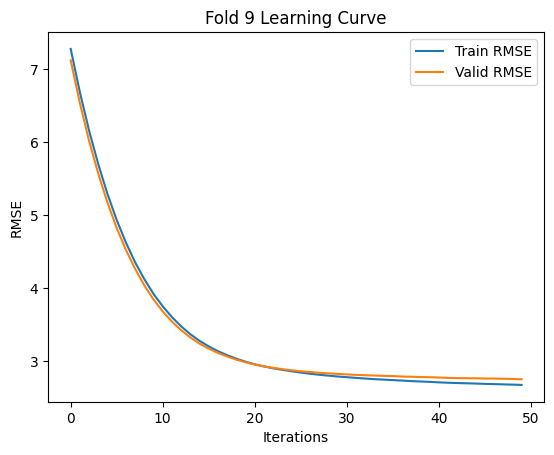

{'RMSE': np.float64(2.7557760379738157), 'R2': 0.8384863122282271, 'MAPE': np.float64(84.74240821195063)}
 Processing Fold 10...
  Train model for Fold 10...
  Plotting learning curve for Fold 10...


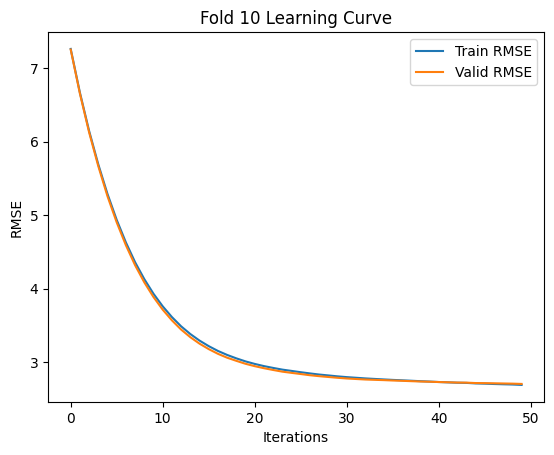

{'RMSE': np.float64(2.702915722635717), 'R2': 0.847082570410031, 'MAPE': np.float64(82.90803642864)}
--------------------------------------------------------

Mean RMSE: 2.755 ± 0.039
Mean R²: 0.843 ± 0.004
--------------------------------------------------------


In [5]:
# check model performance
check_model_performance(site_data, predictors, y_col, reg, n_folds= 10)

# 03 Gapfill
**Parameters**

- `site_data` (`pandas.DataFrame`)  
  Full dataset (may contain missing values in `y_col`).

- `predictors` (`list` of `str`)  
  Column names used as predictors (X).

- `y_col` (`str`)  
  Column name of the target variable (y).

- `site_data_dir` (`pathlib.Path`)  
  Directory where output CSV will be saved.

- `reg` (`object`)  
  Regression model with `fit`/`predict` methods (e.g., `XGBRegressor`).

- `plot` (`bool`, optional, default=`False`)  
  If `True`, generate plots of observed vs. predicted values.

**Returns**

- `pandas.DataFrame`  
  Original dataframe with two new columns:
  - `XGB_FC_fall`: model predictions for all rows  
  - `XGB_FC_f`: observed values when available, otherwise filled with predictions


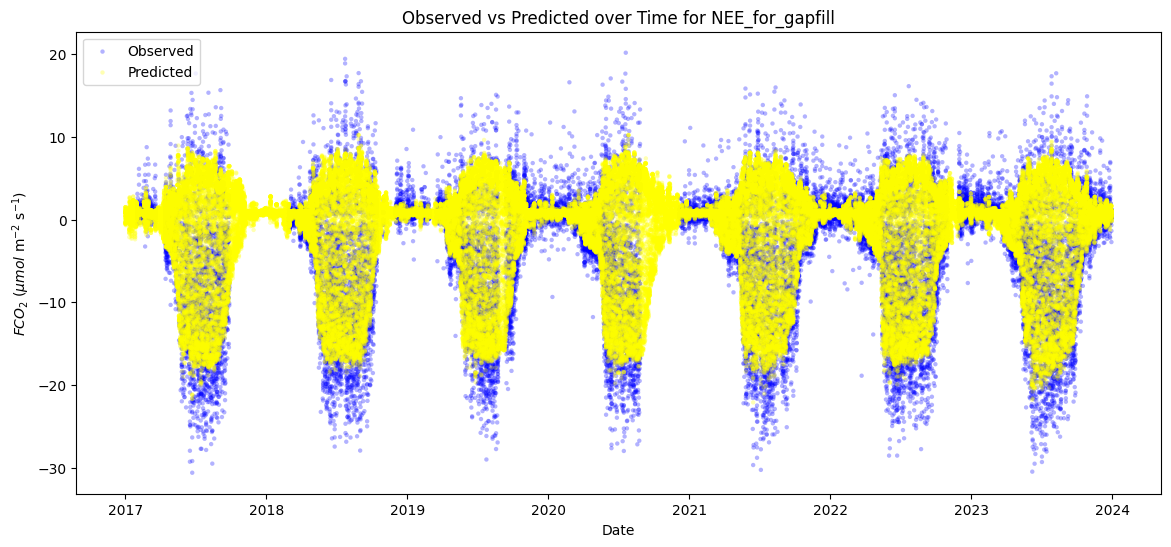

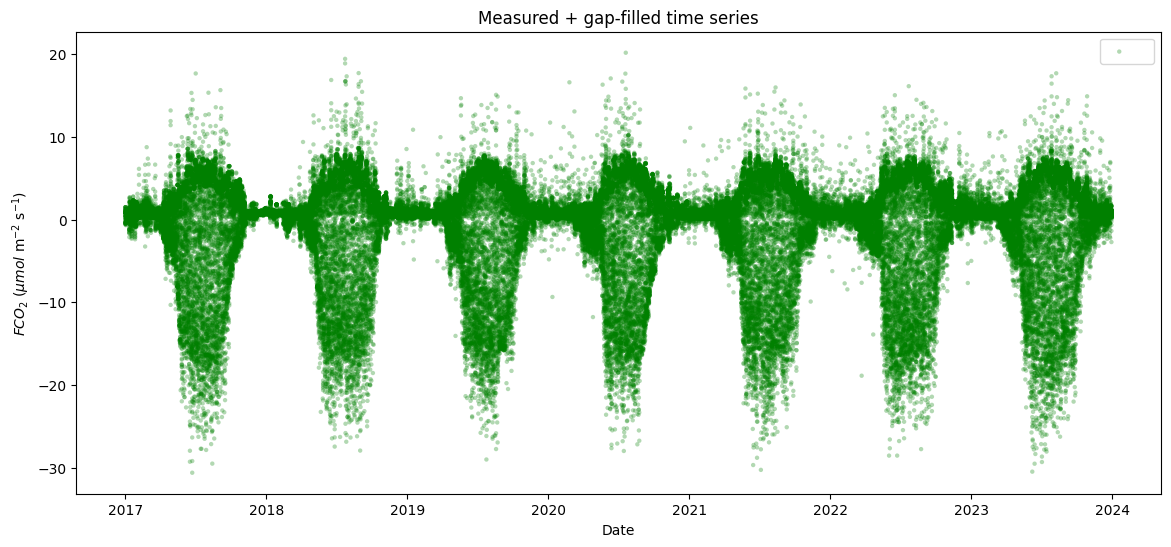

In [6]:
df_pred_FC = get_accurate_prediction(site_data, predictors, y_col, reg, plot=True)

# 04 Feature importances
**Parameters**

- `site_data_no_na` (`pandas.DataFrame`)  
  Input dataset with no missing values.

- `predictors` (`list` of `str`)  
  List of column names in `site_data_no_na` to be used as predictors (features).

- `y_col` (`str`)  
  Column name of the target variable in `site_data_no_na`.

- `site_data_dir` (`pathlib.Path`)  
  Directory where the feature importance CSV (and optionally plots) will be saved.

- `reg` (`object`)  
  Regression model with `fit`, `predict`, and `feature_importances_` attributes  
  (e.g., `XGBRegressor`).


**Returns**

- `pandas.DataFrame`  
  DataFrame containing features and their importance values, sorted in descending order.


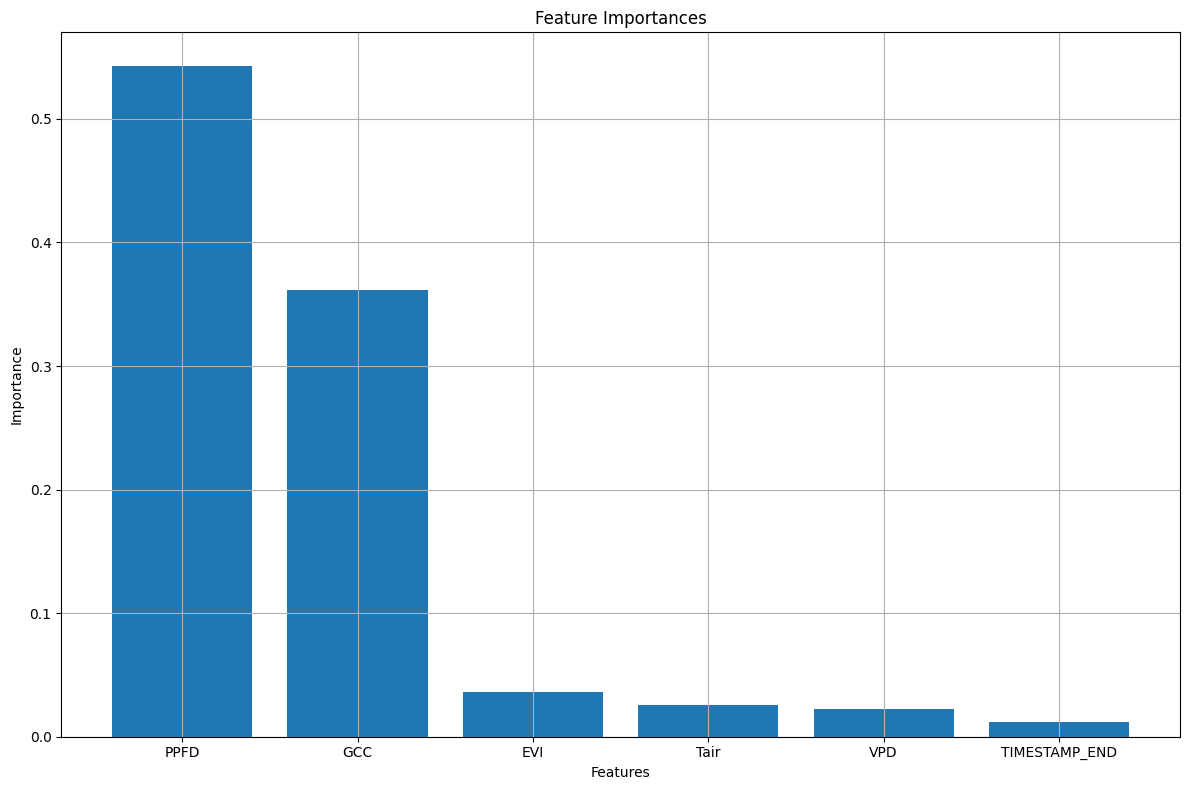

,Feature_Importances,predictors
5,0.542887,PPFD
1,0.361192,GCC
2,0.036073,EVI
3,0.025837,Tair
4,0.022268,VPD
0,0.011742,TIMESTAMP_END


In [7]:
check_feature_importance(site_data, predictors, y_col, reg)

# 05 Compute annual sums and monthly sums

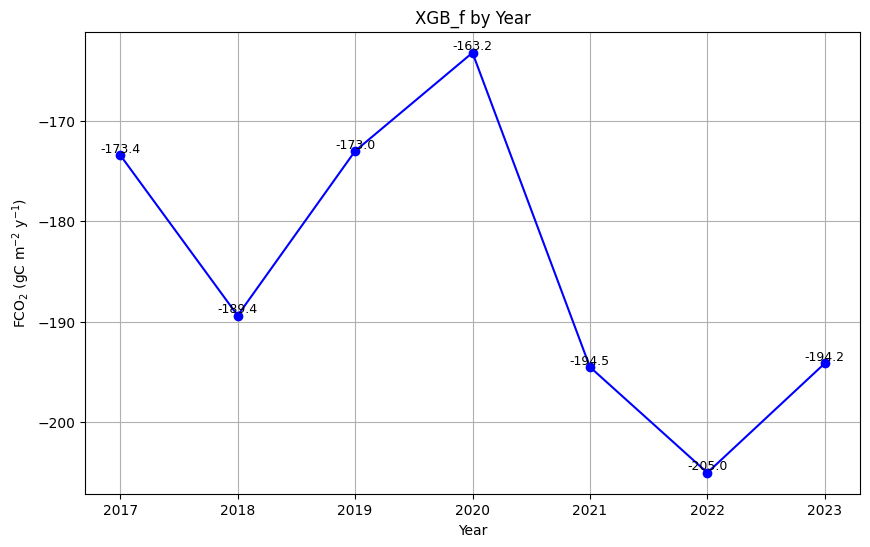

,Year,annual_sum
0,2017,-173.432357
1,2018,-189.398174
2,2019,-173.030032
3,2020,-163.244639
4,2021,-194.520744
5,2022,-205.038860
6,2023,-194.154325


In [9]:
cal_FC_annual_sum(df_pred_FC, "XGB_f", 2017, 2023, plot = True)

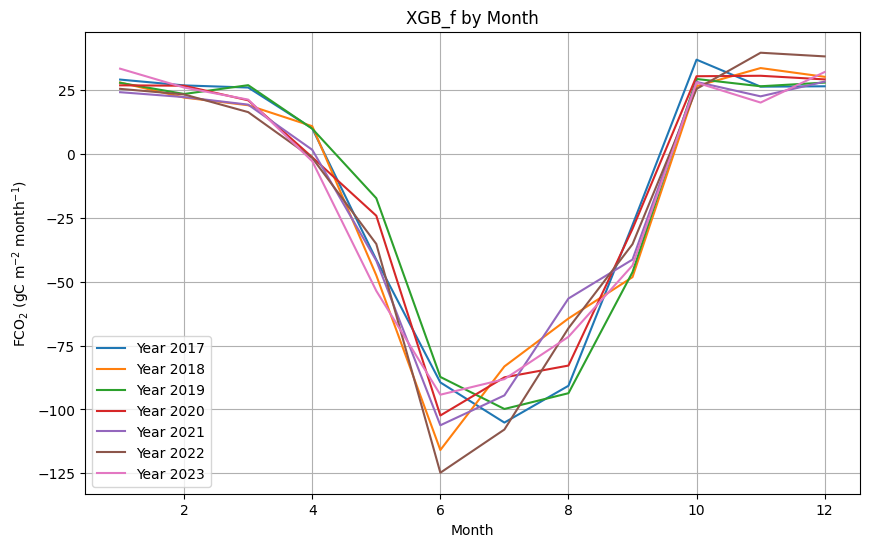

,Year,Month,monthly_sum
0,2017,1,29.042163
1,2017,2,26.762922
2,2017,3,25.932826
3,2017,4,9.930832
4,2017,5,-41.450485
...,...,...,...
79,2023,8,-71.600762
80,2023,9,-43.676442
81,2023,10,27.863257
82,2023,11,20.049091


In [10]:
cal_FC_monthly_sum(df_pred_FC, "XGB_f", 2017, 2023, plot=True)

# 06 Uncertainty in annual sums for FCO2 (experimental)

`get_synthetic_data`

The function generates synthetic datasets by first randomly dropping a fraction of rows to simulate missing data and then performing bootstrap sampling (sampling with replacement) to create multiple datasets that reflect the variability of the original data.

`train_on_synthetic_predict`

Train XGBoost models on bootstrap datasets and predict on original site_data.

In [11]:
boot_datasets = get_synthetic_data(
    original_data=site_data,
    n_bootstrap=20, #  Number of synthetic datasets to generate
    drop_fraction=0.33, #  Fraction of rows to randomly drop before bootstrap sampling
    sample_size= int(0.8 * len(site_data)), # Number of rows to sample in each bootstrap dataset
    gapfill_cols= "NEE_for_gapfill",
    random_state=42
)
synthetic_predictions = train_on_synthetic_predict(site_data, boot_datasets, predictors, y_col)

In [14]:
# List to store annual sums for synthetic data
annual_sums_list = []

for col in synthetic_predictions.columns:
    # Create a temporary dataframe with predictions
    temp_df = site_data.copy()
    temp_df['Pred'] = synthetic_predictions[col]

    # Compute annual sums
    agg = cal_FC_annual_sum(
        data=temp_df,
        var_name='Pred',
        start_year=2017,
        end_year=2023,
        plot = False
    )

    # Keep only Year and annual_sum
    annual_sums_list.append(agg[['Year', 'annual_sum']])

# Combine all bootstraps
all_annual_sums = pd.concat(annual_sums_list, axis=1)

# The concatenation duplicates Year columns, so keep the first one and use the rest as data
years = all_annual_sums.iloc[:, 0]
annual_values = all_annual_sums.iloc[:, 1::2]  # Every second column is annual_sum

# Compute mean and std across bootstraps (synthetic datata) for each year
mean_vals = annual_values.mean(axis=1)
std_vals = annual_values.std(axis=1)

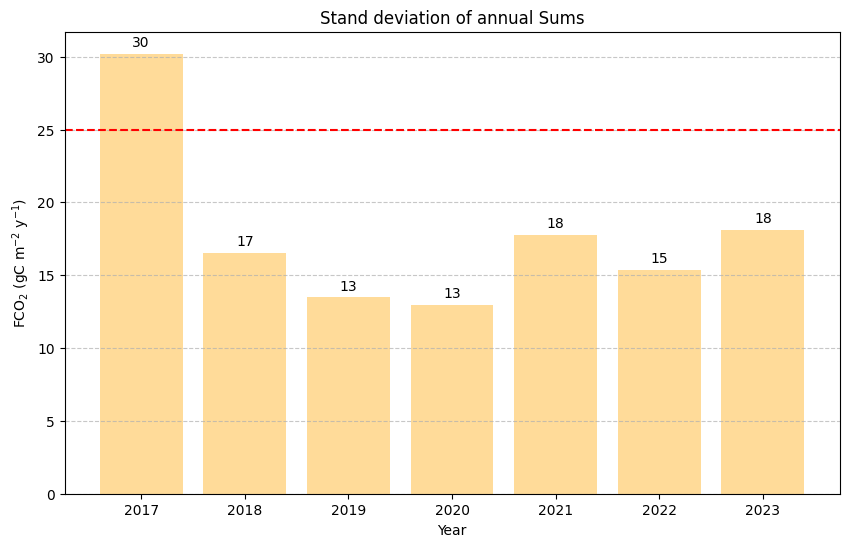

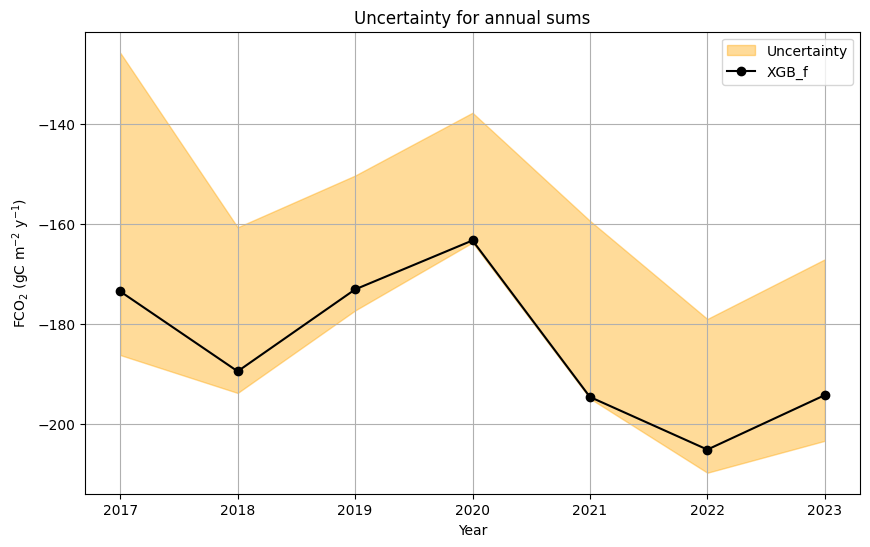

In [17]:
# Visualise the output
import matplotlib.pyplot as plt
# plot 1: barplot for SD of annual sums
plt.figure(figsize=(10, 6))
bars = plt.bar(years, std_vals, color='orange', alpha=0.4)

# Add SD values as text above each bar
for bar, sd in zip(bars, std_vals):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 0.01*max(std_vals),  # slightly above the bar
             f'{sd:.0f}', ha='center', va='bottom', fontsize=10)
plt.axhline(y=25, color='red', linestyle='--', linewidth=1.5, label='y = 25')
plt.xlabel('Year')
plt.ylabel(r'FCO$_2$ (gC m$^{-2}$ y$^{-1}$)')
plt.title('Stand deviation of annual Sums')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# plot 2: annual sums from actual gapfilling vs SD of annual sums
plt.figure(figsize=(10, 6))
# Red shaded area for annual sums from synthetic data
plt.fill_between(years, mean_vals - std_vals, mean_vals + std_vals, color='orange', alpha=0.4, label='Uncertainty')
# Plot the original XGB_FC_f predictions
annual_sum_orig = cal_FC_annual_sum(df_pred_FC, var_name='XGB_f', start_year=years.min(), end_year=years.max(), plot=False)
plt.plot(annual_sum_orig['Year'], annual_sum_orig['annual_sum'], marker='o', linestyle='-', color='black', label='XGB_f')
plt.xlabel('Year')
plt.ylabel(r'FCO$_2$ (gC m$^{-2}$ y$^{-1}$)')
plt.title('Uncertainty for annual sums')
plt.legend()
plt.grid(True)
plt.show()

# 07 Example usage: gapfill LE

Step 1: Shuffle & assign folds ...
Step 2: Train & evaluate for each fold ...
 Processing Fold 1...
  Train model for Fold 1...
  Plotting learning curve for Fold 1...


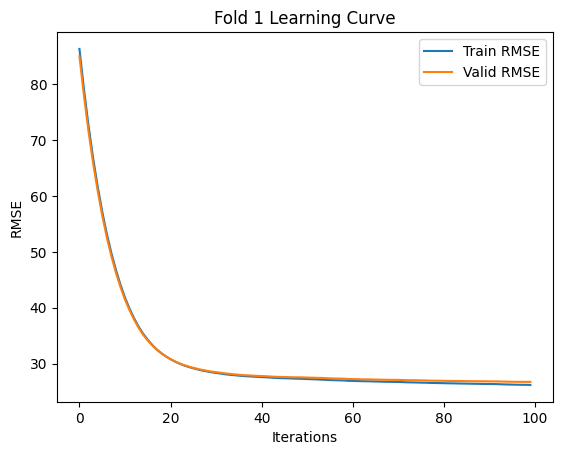

{'RMSE': np.float64(26.71143668737923), 'R2': 0.8854521094151219, 'MAPE': np.float64(179.39554864766563)}
 Processing Fold 2...
  Train model for Fold 2...
  Plotting learning curve for Fold 2...


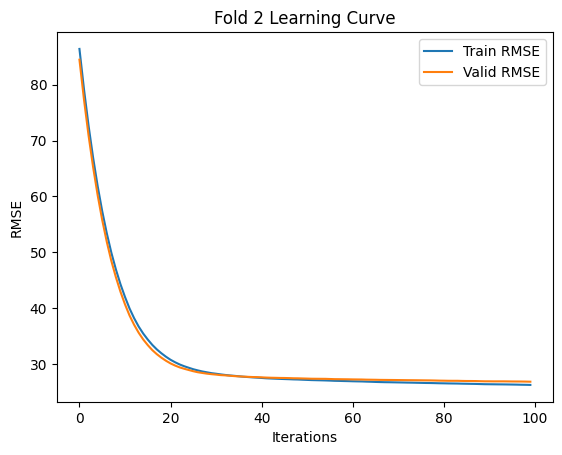

{'RMSE': np.float64(26.829797514435292), 'R2': 0.8817244342029769, 'MAPE': np.float64(193.6093135810287)}
 Processing Fold 3...
  Train model for Fold 3...
  Plotting learning curve for Fold 3...


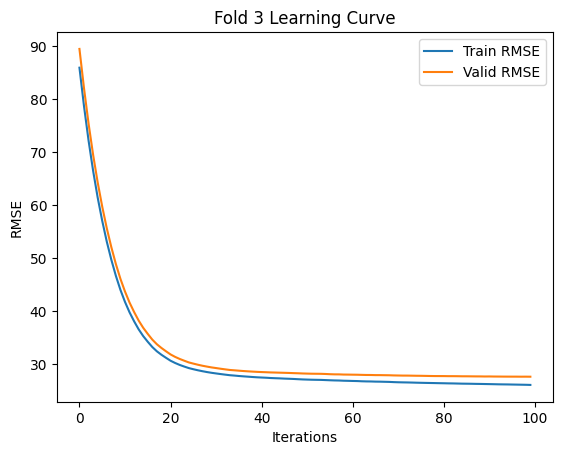

{'RMSE': np.float64(27.59324280545251), 'R2': 0.8884733349414065, 'MAPE': np.float64(190.04960400609042)}
 Processing Fold 4...
  Train model for Fold 4...
  Plotting learning curve for Fold 4...


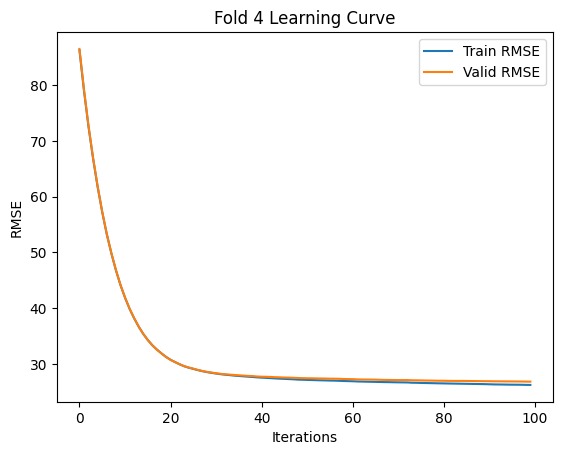

{'RMSE': np.float64(26.830227799329062), 'R2': 0.8864000089269519, 'MAPE': np.float64(216.1314880017199)}
 Processing Fold 5...
  Train model for Fold 5...
  Plotting learning curve for Fold 5...


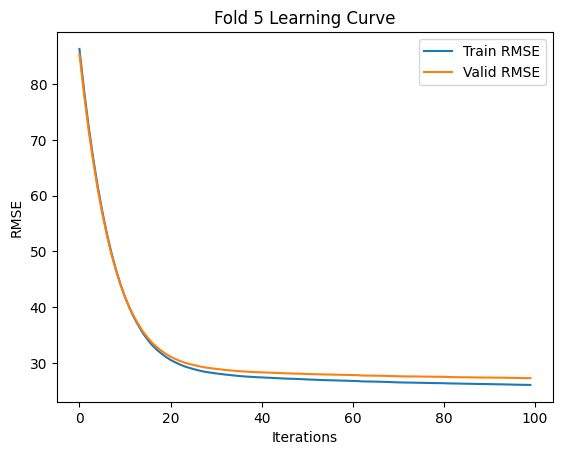

{'RMSE': np.float64(27.268570730291373), 'R2': 0.8807449589063768, 'MAPE': np.float64(187.55071587537088)}
 Processing Fold 6...
  Train model for Fold 6...
  Plotting learning curve for Fold 6...


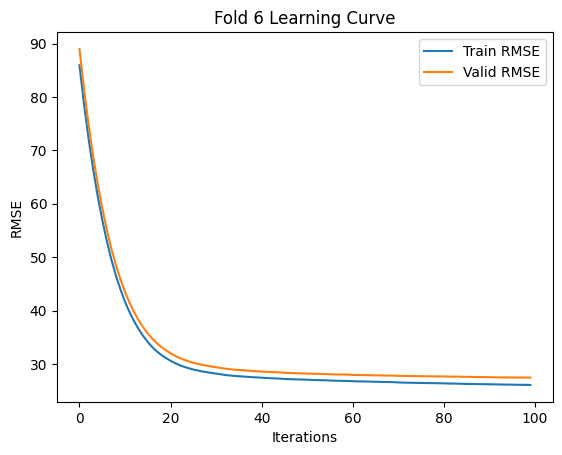

{'RMSE': np.float64(27.442031070938114), 'R2': 0.8885919983667774, 'MAPE': np.float64(171.1168119416333)}
 Processing Fold 7...
  Train model for Fold 7...
  Plotting learning curve for Fold 7...


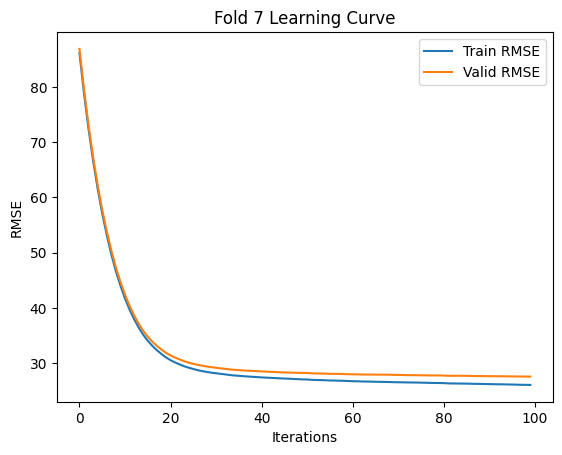

{'RMSE': np.float64(27.59803010709465), 'R2': 0.8814547786208408, 'MAPE': np.float64(165.38821212976887)}
 Processing Fold 8...
  Train model for Fold 8...
  Plotting learning curve for Fold 8...


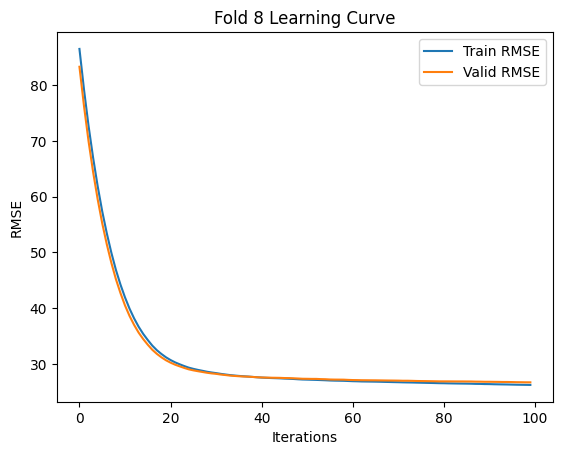

{'RMSE': np.float64(26.696626189314152), 'R2': 0.8815363024932545, 'MAPE': np.float64(202.40361426484822)}
 Processing Fold 9...
  Train model for Fold 9...
  Plotting learning curve for Fold 9...


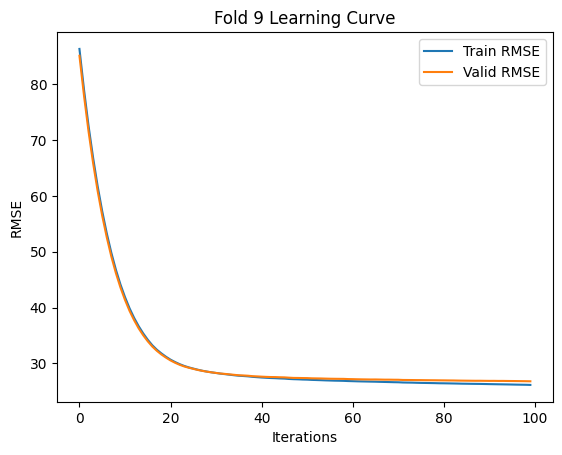

{'RMSE': np.float64(26.788856870970033), 'R2': 0.8844717671755457, 'MAPE': np.float64(198.36267152021148)}
 Processing Fold 10...
  Train model for Fold 10...
  Plotting learning curve for Fold 10...


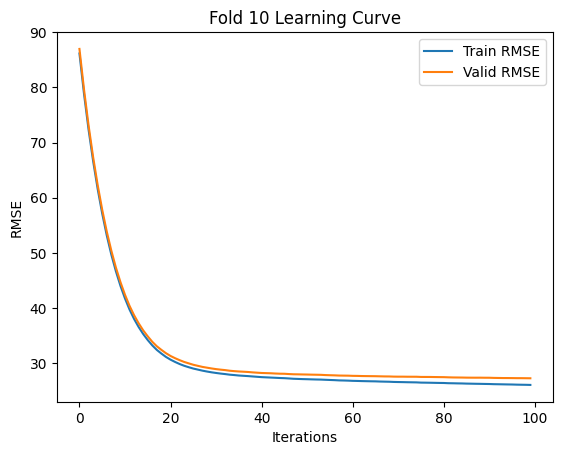

{'RMSE': np.float64(27.250254632167927), 'R2': 0.8849314469962529, 'MAPE': np.float64(178.25571209480086)}
--------------------------------------------------------

Mean RMSE: 27.101 ± 0.349
Mean R²: 0.884 ± 0.003
--------------------------------------------------------


In [18]:
predictors = ['TIMESTAMP_END', 'GCC', 'EVI', 'Tair', 'VPD', 'PPFD']
y_col = "LE_for_gapfill"
file_name = "data_for_XGB_BART_NEON.csv"
# load data
data_LE = load_data(site_data_dir, file_name, y_col, plot=False)
# load model object after hyperparamter tuning
model_path = model_dir / "XGB_model_LE_for_gapfill.pkl"
reg = joblib.load(model_path)
# check model performance
check_model_performance(data_LE, predictors, y_col, reg, n_folds= 10)

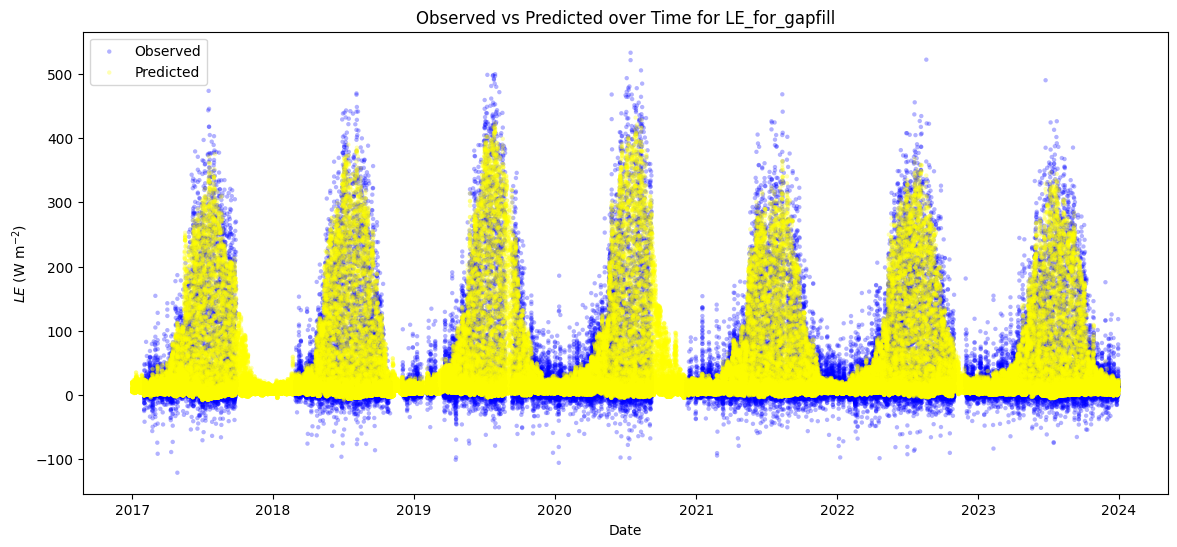

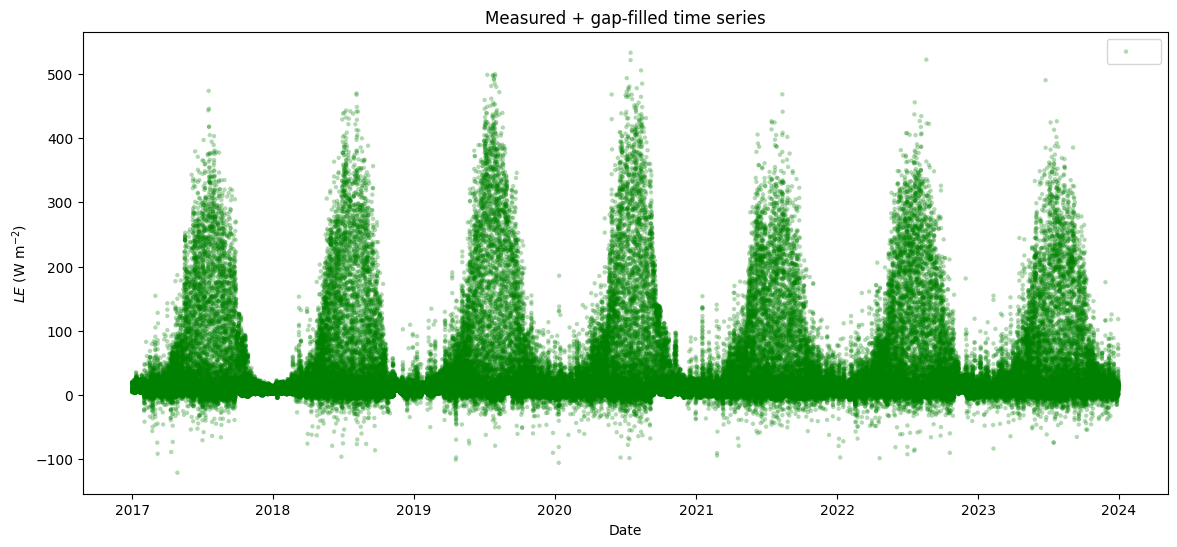

In [19]:
# do gapfilling
df_pred_LE = get_accurate_prediction(data_LE, predictors, y_col, reg, plot=True)

In [20]:
# feature importances
check_feature_importance(data_LE, predictors, y_col, reg, plot = False)

,Feature_Importances,predictors
5,0.605867,PPFD
1,0.217352,GCC
3,0.102095,Tair
2,0.035441,EVI
4,0.022325,VPD
0,0.016919,TIMESTAMP_END


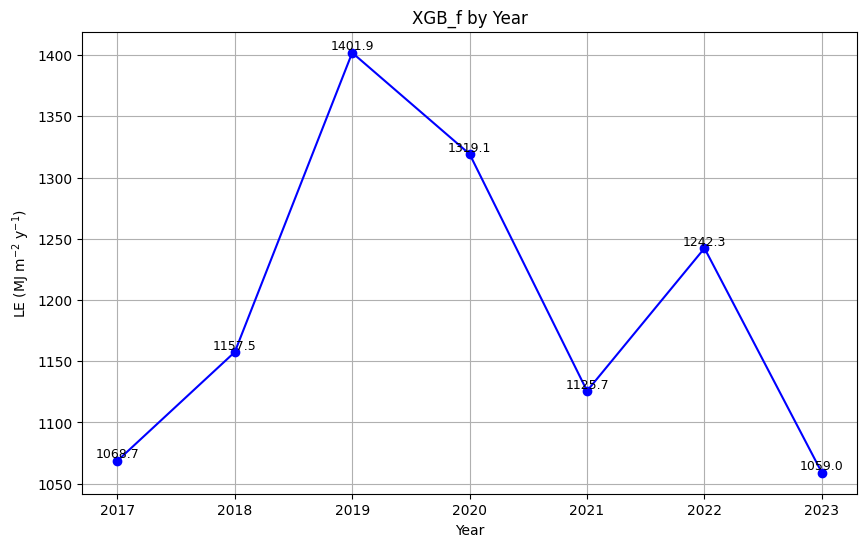

,Year,annual_sum
0,2017,1068.677848
1,2018,1157.488517
2,2019,1401.915613
3,2020,1319.146422
4,2021,1125.741230
5,2022,1242.290842
6,2023,1058.965548


In [21]:
# compute annual sums
cal_LE_annual_sum(df_pred_LE, "XGB_f", 2017, 2023, plot = True)

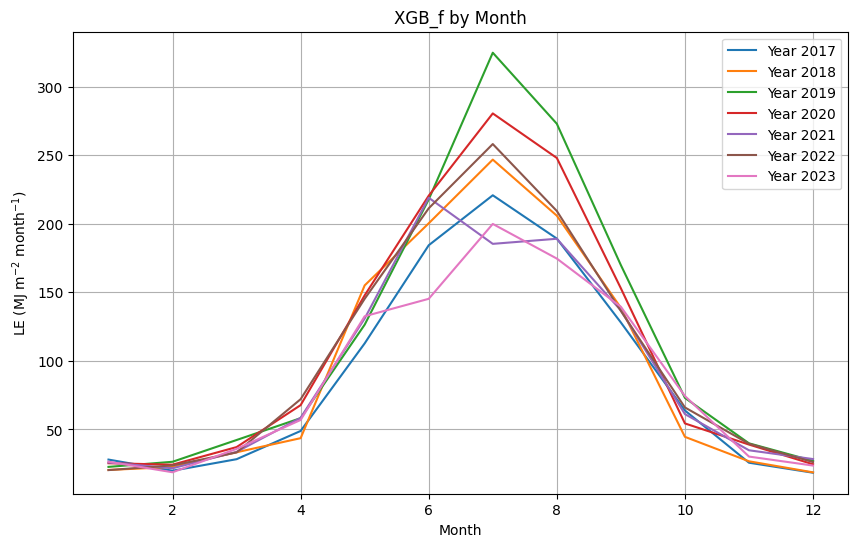

,Year,Month,monthly_sum
0,2017,1,28.015334
1,2017,2,19.885084
2,2017,3,28.298517
3,2017,4,48.876806
4,2017,5,112.742388
...,...,...,...
79,2023,8,174.570421
80,2023,9,139.417474
81,2023,10,74.366903
82,2023,11,30.214782


In [22]:
# compute monthly sums
cal_LE_monthly_sum(df_pred_LE, "XGB_f", 2017, 2023, plot = True)

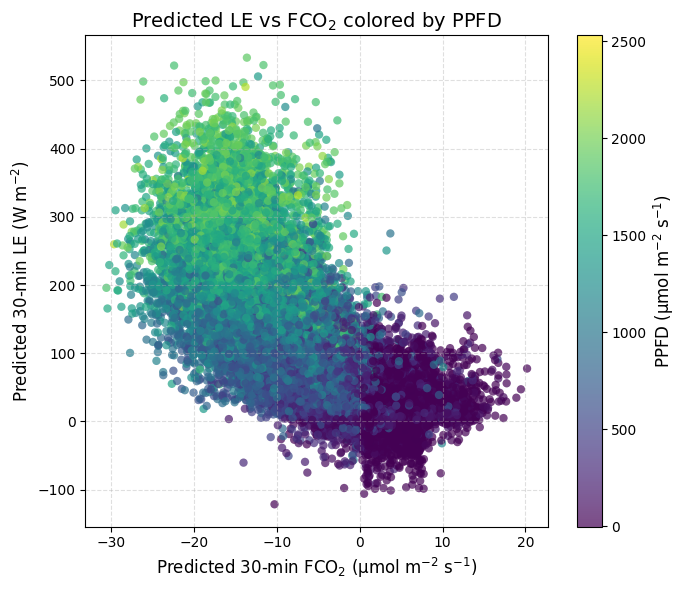

In [27]:
plt.figure(figsize=(7, 6))

# Scatter plot colored by PPFD
sc = plt.scatter(
    df_pred_FC["XGB_f"],
    df_pred_LE["XGB_f"],
    c=df_pred_FC["PPFD"],      # color by PPFD
    cmap='viridis',             # you can choose a different colormap
    alpha=0.7,
    edgecolor='none'
)

# Add colorbar
cbar = plt.colorbar(sc)
cbar.set_label('PPFD (µmol m$^{-2}$ s$^{-1}$)', fontsize=12)

# Axis labels and title
plt.xlabel(r'Predicted 30-min FCO$_2$ (µmol m$^{-2}$ s$^{-1}$)', fontsize=12)
plt.ylabel(r'Predicted 30-min LE (W m$^{-2}$)', fontsize=12)
plt.title('Predicted LE vs FCO$_2$ colored by PPFD', fontsize=14)

# Add grid and layout adjustments
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

